In [14]:
# AI (copilot) was used to support code development
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
# Import full_charging_df from feather file 
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
full_charging_df

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,invalidDoneDisconnectTimespan
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65032,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12-07:00,2019-07-01 18:37:18-07:00,2019-07-01 16:14:33-07:00,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,...,Monday,2019,False,14,18,16,85.350000,228.100000,0.374178,False
65033,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45-07:00,2019-07-01 17:39:48-07:00,2019-07-01 17:39:48-07:00,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,...,Monday,2019,False,14,17,17,161.600000,161.050000,1.003415,True
65034,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21-07:00,2019-07-01 17:58:50-07:00,2019-07-01 17:58:50-07:00,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,...,Monday,2019,False,15,17,17,177.033333,176.483333,1.003116,True
65035,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44-07:00,2019-07-01 19:03:36-07:00,2019-07-01 19:03:36-07:00,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,...,Monday,2019,False,15,19,19,220.366667,219.866667,1.002274,True


Criteria that can be used to differeniate a public site near a university from a private site of a company:
1. A private company site will show fewer charging events on the weekend compared to a public site
2. The start and end time of charging events on a company site will most likely be between 07:00 and 09:00 am and 4:00 and 6:00 pm. A public site, especially near a university, will have charging events later in the evening, because a few lectures are also held after 06:00 pm
3. Since a public site is not as bound to standard working hours as a private one, the standard deviation of the connection duration will be higher for public sites

The following graphs show these criteria in the two sites.

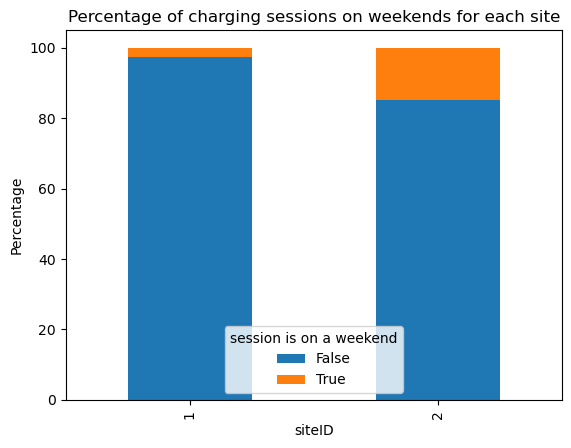

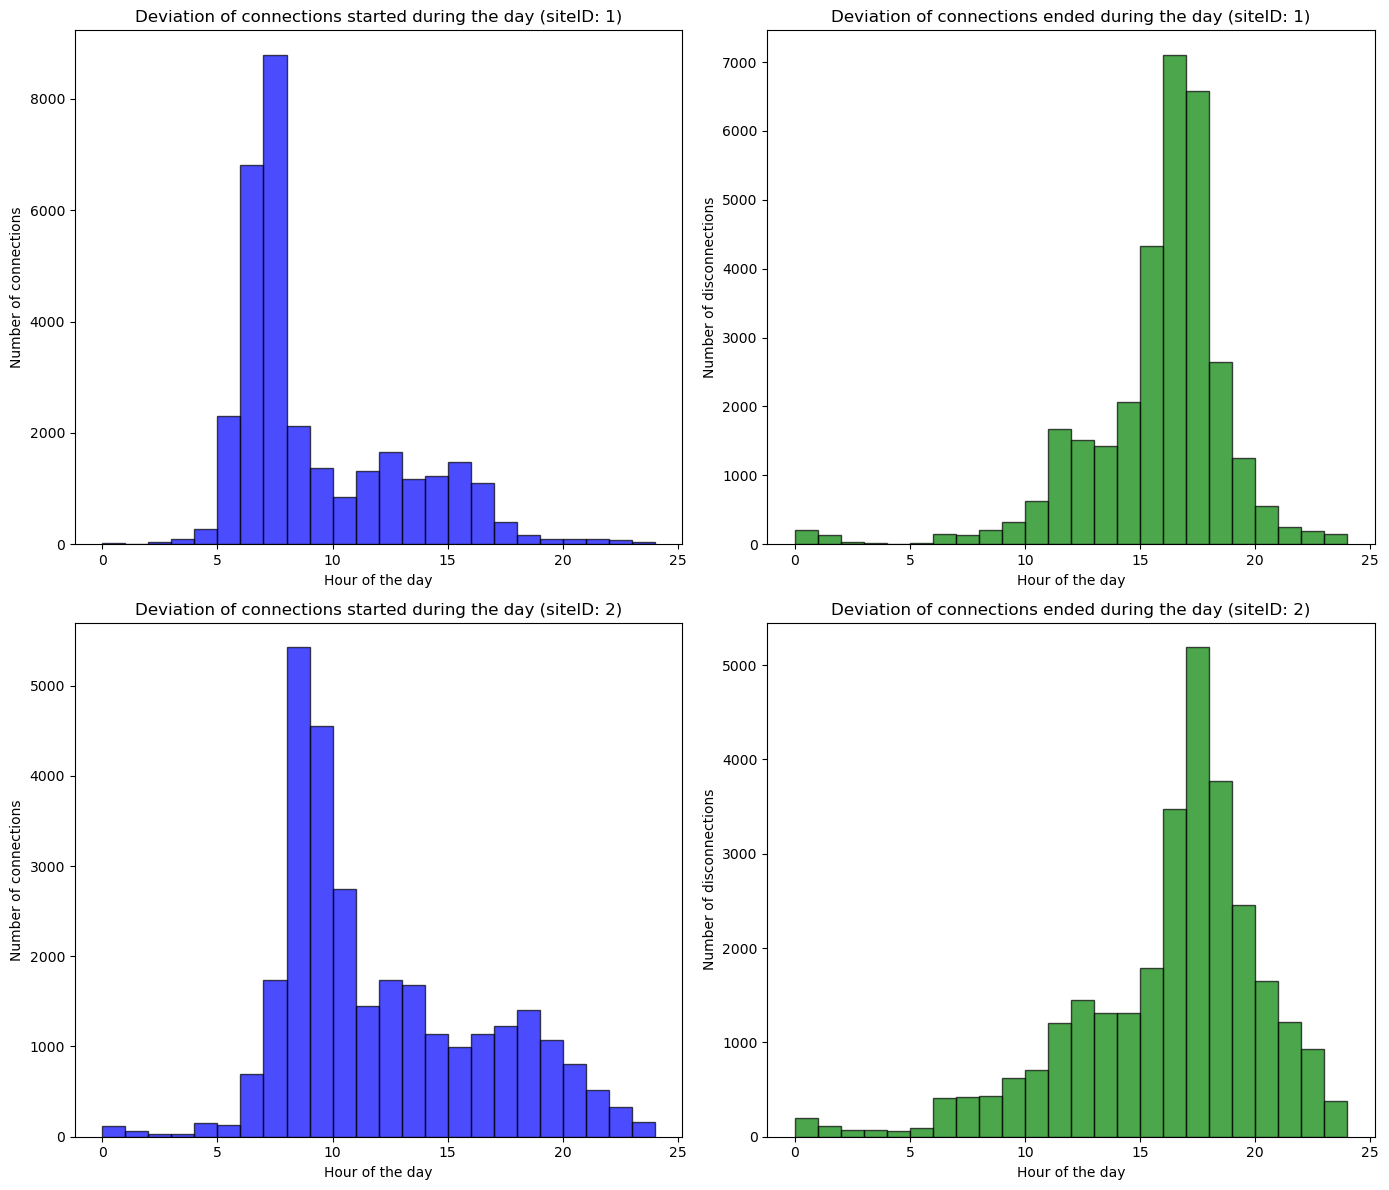

Statistics for connected_duration
            mean       std
siteID                    
1       6.871393  3.504151
2       5.844328  6.031545


In [16]:
# A plot that shows the percentage of entries with isWeekend is true and false for each siteID (code generated with help of copilot)
# Calculate percentage of entries with isWeekend True and False for each siteID
percentage_df = full_charging_df.groupby(['siteID', 'isWeekend']).size().unstack(fill_value=0)
percentage_df = percentage_df.div(percentage_df.sum(axis=1), axis=0) * 100

# Plot for Weekend
percentage_df.plot(kind='bar', stacked=True)
plt.title('Percentage of charging sessions on weekends for each site')
plt.xlabel('siteID')
plt.ylabel('Percentage')
plt.legend(title='session is on a weekend', loc='lower center') 
plt.show()

# New columns based on connectionTime and disconnectTime
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour
full_charging_df['disconnectHour'] = full_charging_df['disconnectTime'].dt.hour

# List of unique siteIDs
site_ids = full_charging_df['siteID'].unique()

# Create Subplots for each siteID
fig, axes = plt.subplots(len(site_ids), 2, figsize=(14, 6 * len(site_ids)))

for i, site_id in enumerate(site_ids):
    site_data = full_charging_df[full_charging_df['siteID'] == site_id]
    
    # Histogram for connectionTime
    axes[i, 0].hist(site_data['connectionHour'], bins=24, range=(0, 24), alpha=0.7, color='blue', edgecolor='black')
    axes[i, 0].set_title(f'Deviation of connections started during the day (siteID: {site_id})')
    axes[i, 0].set_xlabel('Hour of the day')
    axes[i, 0].set_ylabel('Number of connections')
    
    # Histogram for disconnectTime
    axes[i, 1].hist(site_data['disconnectHour'], bins=24, range=(0, 24), alpha=0.7, color='green', edgecolor='black')
    axes[i, 1].set_title(f'Deviation of connections ended during the day (siteID: {site_id})')
    axes[i, 1].set_xlabel('Hour of the day')
    axes[i, 1].set_ylabel('Number of disconnections')

# Layout and plot
plt.tight_layout()
plt.show()

# Convert connected_duration into from timespan to hours and show the average and standard deviation for each siteID
full_charging_df['connected_duration'] = full_charging_df['connected_duration'] / 60
print("Statistics for connected_duration")
print(full_charging_df.groupby('siteID')['connected_duration'].agg(['mean', 'std']))


Based on the previous criteria all these graphs support that ID 1 is the private site of the company and ID 2 is the public site near the university. The fact that the mean connected_duration of the company site is below 8 hours can be explained e.g. by part-time workers or leaving for lunch brakes.

In [ ]:
# New siteType column
full_charging_df["siteType"] = full_charging_df["siteID"].apply(lambda x: "Public" if x == 2 else "Private")